In [1]:
import os 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy
import cartopy.crs as ccrs
from radar_api.io import get_database
from shapely.geometry import Polygon, MultiPolygon

In [2]:
data_dir = "/home/alfonso/Downloads/Folder_2025_02_05_11_50_archive"
db_wmo_fpath = os.path.join(data_dir, "wmo_db.parquet")
db_cinrad_fpath = os.path.join(data_dir, "cinrad_db.parquet")

In [3]:
# Load databases
df_wmo = pd.read_parquet(db_wmo_fpath, engine="pyarrow")
df_cinrad = pd.read_parquet(db_cinrad_fpath, engine="pyarrow")

# Subset countries from WMO database 
np.unique(df_wmo["Country"])
country_to_remove = ["United States of America (the)", "Finland"]
df_wmo = df_wmo[~df_wmo["Country"].isin(country_to_remove)]

In [4]:
df_api = get_database()
df_api = df_api.rename({"latitude": "Latitude", "longitude": "Longitude", "altitude": "Elevation", "radar_band": "Band"}, axis=1)
len(df_api)

243

In [5]:
# Create unique dataframe 
df = pd.concat([df_wmo, df_cinrad, df_api])
df["radar_api"] = ~df["network"].isna()

# Select only required variables
variables = ['Latitude', 'Longitude', 'Band', "radar_api"]
df = df[variables]

# Add radar coverage radius based on band
# - Default to 150 km if unknown (assuming C band)
df["Radius"] = 100_000

df.loc[df["Band"] == "X", "Radius"] = 60_000
df.loc[df["Band"] == "C", "Radius"] = 200_000
df.loc[df["Band"] == "S", "Radius"] = 250_000

In [6]:
# Convert the DataFrame to a GeoDataFrame
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['Longitude'], df['Latitude'])
)

# Define a CRS for the GeoDataFrame that corresponds to geographic coordinates
gdf.set_crs(epsg=4326, inplace=True)

# Convert data to the World Equidistant Cylindrical Projection 
# - Equidistant projection can reasonably preserve distances from any point to every other point.
# - THis projection uses meters 
gdf = gdf.to_crs(epsg=4087)  
 
# Buffer the points by 200 km
gdf['geometry'] = gdf['geometry'].buffer(df["Radius"])  # Buffer by 200,000 meters (200 km)

# Convert back to geographic coordinates to display on a lat-lon map
gdf = gdf.to_crs(epsg=4326)

# Remove invalid geometries 
gdf = gdf[gdf.geometry.is_valid]

# Identify radars not included in RADAR-API 
gdf_unavailable = gdf[~gdf["radar_api"]]
gdf_available = gdf[gdf["radar_api"]]

In [7]:
#### Define global polygon without radar coverage 
# crs = ccrs.Robinson()
# dir(crs)
# x_limits = crs.x_limits 
# y_limits = crs.y_limits

# Retrieve radar coverage polygons 
holes = gdf.geometry.values 

# Remove invalid geometries 
holes = [hole for hole in holes if hole.is_valid]

# Create MultiPolygon 
hole_multipolygon = MultiPolygon(holes).buffer(0)
 
# Create a global polygon based on limits
x_limits = (-180, 180)
y_limits = (-90, 90)
global_polygon = Polygon([
    (x_limits[0], y_limits[0]),
    (x_limits[0], y_limits[1]),
    (x_limits[1], y_limits[1]),
    (x_limits[1], y_limits[0])
])

# Create polygon with missing radar coverage
coverage_poly = global_polygon.symmetric_difference(hole_multipolygon) 

####---------------------------------------------------------------------------
#### Define polygon with radar available in RADAR-API 
coverage_radar_available = MultiPolygon(gdf_available.geometry.values).buffer(0)

####---------------------------------------------------------------------------
#### Define polygon with radar not included in RADAR-API 
coverage_radar_unavailable = MultiPolygon(gdf_unavailable.geometry.values).buffer(0)
coverage_radar_unavailable = coverage_radar_unavailable.difference(coverage_radar_available)


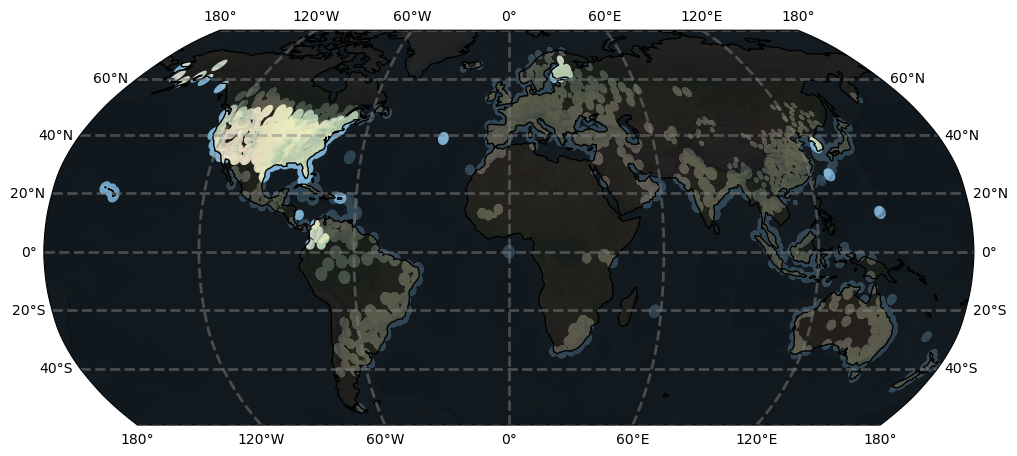

In [22]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.Robinson()})

# Set the title for the plot.
# ax.set_title('Global Ground Radar Coverage')

# Add the stock image, which includes coastlines, borders, and land.
ax.stock_img()

# Optionally, add coastlines for better visualization of boundaries.
ax.coastlines()

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=2, color='gray', alpha=0.5, linestyle='--')


# Add global radar coverage
ax.add_geometries(coverage_poly, facecolor="black", alpha=0.85, crs=cartopy.crs.PlateCarree())

# Draw polygons of radars not included in RADAR-API 
ax.add_geometries(coverage_radar_unavailable, facecolor="black", alpha=0.6, crs=cartopy.crs.PlateCarree())

# Set extent 
ax.set_extent([-180, 180, -60, 80])


# Display the plot
plt.savefig("radar_coverag.jpeg", dpi=150, bbox_inches='tight')
plt.show()